In [25]:
import torchaudio
from pathlib import Path
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

In [18]:
ROOT_DIR = Path("..").resolve()
DATA_RAW_DIR = ROOT_DIR / "data_raw"

print(f"Loading from/Downloading to: {DATA_RAW_DIR}")
dataset = torchaudio.datasets.LJSPEECH(root=DATA_RAW_DIR, download=True)

Loading from/Downloading to: /Users/janek/dev/uwr/tts/data_raw


In [19]:
dataset_root = DATA_RAW_DIR / "LJSpeech-1.1"
csv_path = dataset_root / "metadata.csv"
df = pd.read_csv(csv_path, sep="|", header=None, names=["ID", "Text", "Normalized"], quoting=3)

print(f"total {len(df)}")
df.head()

total 13100


,ID,Text,Normalized
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


In [23]:
sample_file = dataset_root / "wavs" / f"{df.iloc[3]['ID']}.wav"
info = sf.info(sample_file)
print(info)

/Users/janek/dev/uwr/tts/data_raw/LJSpeech-1.1/wavs/LJ001-0004.wav
samplerate: 22050 Hz
channels: 1
duration: 5.139 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]


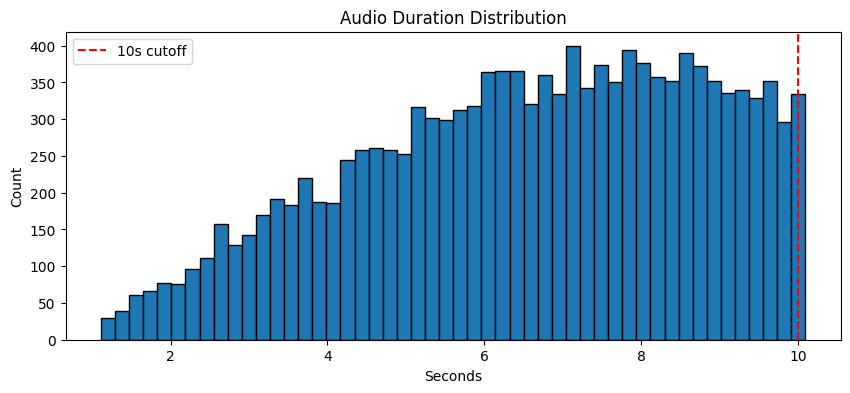

In [30]:
durations = []
wav_dir =dataset_root / "wavs"
for file_id in df['ID']:
    path = wav_dir / f"{file_id}.wav"
    durations.append(sf.info(path).duration)

df['duration'] = durations

plt.figure(figsize=(10, 4))
plt.hist(df['duration'], bins=50, edgecolor='black')
plt.title("Audio Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.axvline(x=10, color='r', linestyle='--', label='10s cutoff')
plt.legend()
plt.show()

In [31]:
df['duration'].describe()

count    13100.000000
mean         6.573823
std          2.185431
min          1.110068
25%          4.987800
50%          6.764127
75%          8.389524
max         10.096190
Name: duration, dtype: float64